# EEG Frequency Band Analysis and Classification

## Goal
In this notebook I want to explores EEG signals and gain familiarity with the subject. I will be looking at eeg data for the first time and try to identify problems, aswell as handel them, in my attempt to classify
between the two mental states of open or closed eyes.

For this task I will be looking at frequency bandpowers and findout, whether my current understanding of the brain is reflected in the data at hand.

The focus will be on letting my curriosity lead me through the different signal processing steps and interpreting the results according to my current knowledge.

## About the dataset

All data is from one continuous 117 second long EEG measurement with the Emotiv EEG Neuroheadset. The eye state was detected via a camera during the EEG measurement and added later manually to the file after analysing the video frames. This way transitions between states happen naturally. The lable '1' indicates the eye-closed state and the lable '0' indicates the eye-open state. All values are in chronological order with the first measured value at the top of the data.

In [89]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.io import arff

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Sanity checks are contained within one function,they are a great way for me to get familiar with the structure of a Dataframe and have a first glance on how eg data looks like. I

In [90]:
from IPython.display import display

def sanity_checks(df, n_samples=5):
    """
    Perform a bunch of sanity checks on a DataFrame:
    - Show first and last rows
    - Show summary statistics (describe)
    - Show missing values
    - Show shape
    """
    
    print("Shape of data:", df.shape, "\n")
    
    print(f"First {n_samples} rows:")
    display(df.head(n_samples))
    
    print(f"\nLast {n_samples} rows:")
    display(df.tail(n_samples))
    
    print("\nSummary statistics:")
    display(df.describe())
    
    print("\nMissing values per column:")
    display(df.info())
    
    print("\nColumn names:", df.columns.tolist())

## Lets do some basic sanity checks:

- Check first 5 rows
- get the shape
- check for null values
- check for spike artifacts

In [91]:
# Load EEG data from ARFF file
data, meta = arff.loadarff('EEG Eye State.arff')
data = pd.DataFrame(data)
data['eyeDetection'] = data['eyeDetection'].astype(int)
sanity_checks(data)

Shape of data: (14980, 15) 

First 5 rows:


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0



Last 5 rows:


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
14975,4281.03,3990.26,4245.64,4116.92,4333.85,4614.36,4074.87,4625.64,4203.08,4221.54,4171.28,4269.23,4593.33,4340.51,1
14976,4276.92,3991.79,4245.13,4110.77,4332.82,4615.38,4073.33,4621.54,4194.36,4217.44,4162.56,4259.49,4590.26,4333.33,1
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49,1
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77,1
14979,4287.69,3997.44,4260.00,4121.03,4333.33,4616.41,4088.72,4638.46,4212.31,4226.67,4167.69,4274.36,4597.95,4350.77,1



Summary statistics:


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,4321.917777,4009.767694,4264.022433,4164.946326,4341.741075,4644.022379,4110.400160,4616.056904,4218.826610,4231.316200,4202.456900,4279.232774,4615.205336,4416.435832,0.448798
std,2492.072174,45.941672,44.428052,5216.404632,34.738821,2924.789537,4600.926543,29.292603,2136.408523,38.050903,37.785981,41.544312,1208.369958,5891.285043,0.497388
min,1030.770000,2830.770000,1040.000000,2453.330000,2089.740000,2768.210000,2086.150000,4567.180000,1357.950000,1816.410000,3273.330000,2257.950000,86.666700,1366.150000,0.000000
25%,4280.510000,3990.770000,4250.260000,4108.210000,4331.790000,4611.790000,4057.950000,4604.620000,4190.770000,4220.510000,4190.260000,4267.690000,4590.770000,4342.050000,0.000000
50%,4294.360000,4005.640000,4262.560000,4120.510000,4338.970000,4617.950000,4070.260000,4613.330000,4199.490000,4229.230000,4200.510000,4276.920000,4603.080000,4354.870000,0.000000
75%,4311.790000,4023.080000,4270.770000,4132.310000,4347.180000,4626.670000,4083.590000,4624.100000,4209.230000,4239.490000,4211.280000,4287.180000,4617.440000,4372.820000,1.000000
max,309231.000000,7804.620000,6880.510000,642564.000000,6474.360000,362564.000000,567179.000000,7264.100000,265641.000000,6674.360000,6823.080000,7002.560000,152308.000000,715897.000000,1.000000



Missing values per column:
<class 'pandas.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   F7            14980 non-null  float64
 2   F3            14980 non-null  float64
 3   FC5           14980 non-null  float64
 4   T7            14980 non-null  float64
 5   P7            14980 non-null  float64
 6   O1            14980 non-null  float64
 7   O2            14980 non-null  float64
 8   P8            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  FC6           14980 non-null  float64
 11  F4            14980 non-null  float64
 12  F8            14980 non-null  float64
 13  AF4           14980 non-null  float64
 14  eyeDetection  14980 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 1.7 MB


None


Column names: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection']


## Dataset Overview

- Number of samples: 14980
- Number of EEG channels: 14
- Sampling frequency: XXXXX Hz
- Labels: XXXXX

Each row represents a time sample (or epoch), and columns correspond
to EEG channels and a class label.

In [92]:
# Number of samples in your EEG recording
eeg_length = data.shape[0]
recording_duration_sec = 117  

# Sampling rate in Hz
sampling_rate = eeg_length / recording_duration_sec
print("Sampling rate (Hz):", sampling_rate)

Sampling rate (Hz): 128.03418803418805


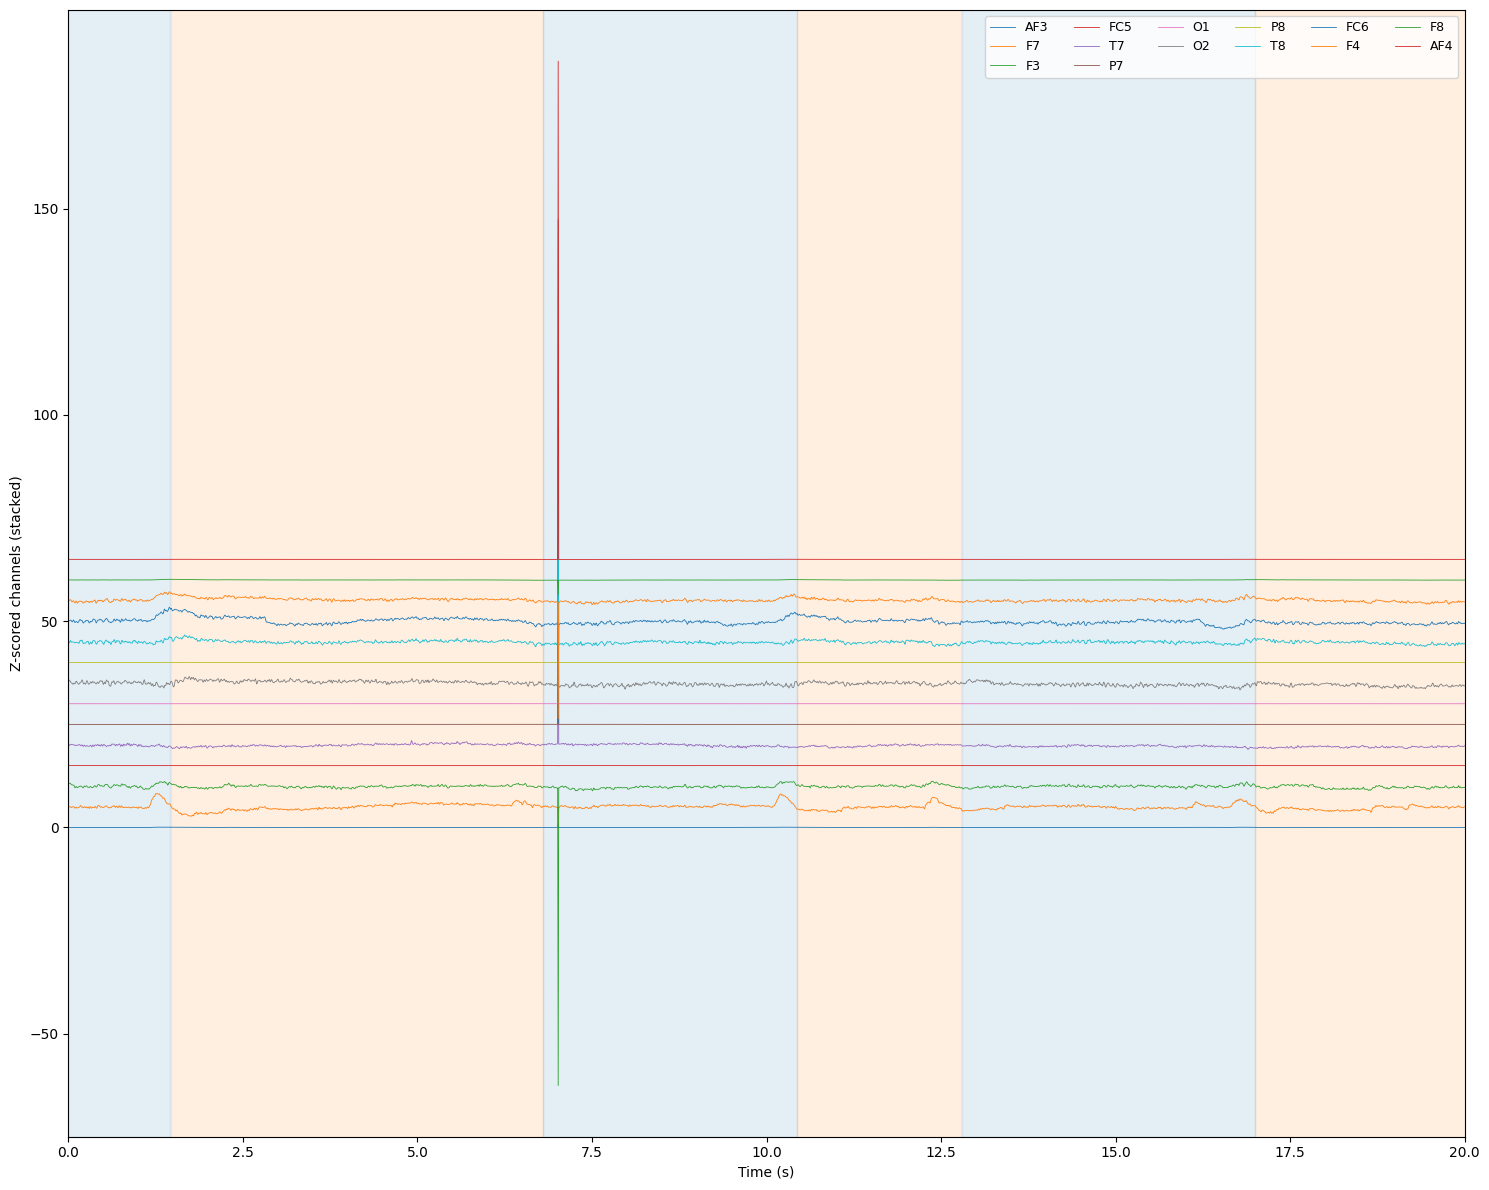

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def plot_eeg(dfs, fs, xlim=(0, 20), label_col=None, sample_range=None):

    if isinstance(dfs, pd.DataFrame):
        dfs = [dfs]
    elif isinstance(dfs, dict):
        dfs = list(dfs.values())

    plt.figure(figsize=(15, 12))
    ax = plt.gca()

    for block_idx, df in enumerate(dfs):

        # EEG only
        if label_col is None:
            eeg_df = df.iloc[:, :-1]
            labels = df.iloc[:, -1]
        else:
            eeg_df = df.drop(columns=[label_col])
            labels = df[label_col]

        # sample slicing
        if sample_range is not None:
            start, end = sample_range
            eeg_df = eeg_df.iloc[start:end]
            labels = labels.iloc[start:end]

        n_samples = len(eeg_df)
        t = np.arange(n_samples) / fs

        # ---- plot EEG ----
        if block_idx < len(dfs) - 1:
            for ch_i, col in enumerate(eeg_df.columns):
                sig = stats.zscore(eeg_df[col], nan_policy="omit")
                ax.plot(t, 5 * ch_i + sig, linewidth=0.3,
                        alpha=0.6, color="k")
        else:
            for ch_i, col in enumerate(eeg_df.columns):
                sig = stats.zscore(eeg_df[col], nan_policy="omit")
                ax.plot(t, 5 * ch_i + sig, linewidth=0.6, label=col)

            ax.legend(ncol=6, fontsize=9)

            # ---- draw true labels as background ----
            lab = labels.to_numpy()

            change = np.where(lab[1:] != lab[:-1])[0] + 1
            segments = np.r_[0, change, len(lab)]

            uniq = np.unique(lab)
            cmap = plt.get_cmap("tab10")
            color_map = {u: cmap(i % 10) for i, u in enumerate(uniq)}

            for s, e in zip(segments[:-1], segments[1:]):
                ax.axvspan(
                    t[s],
                    t[e-1],
                    color=color_map[lab[s]],
                    alpha=0.12,
                    zorder=0
                )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Z-scored channels (stacked)")
    ax.set_xlim(xlim)
    plt.tight_layout()
    plt.show()

plot_eeg(data, 128)

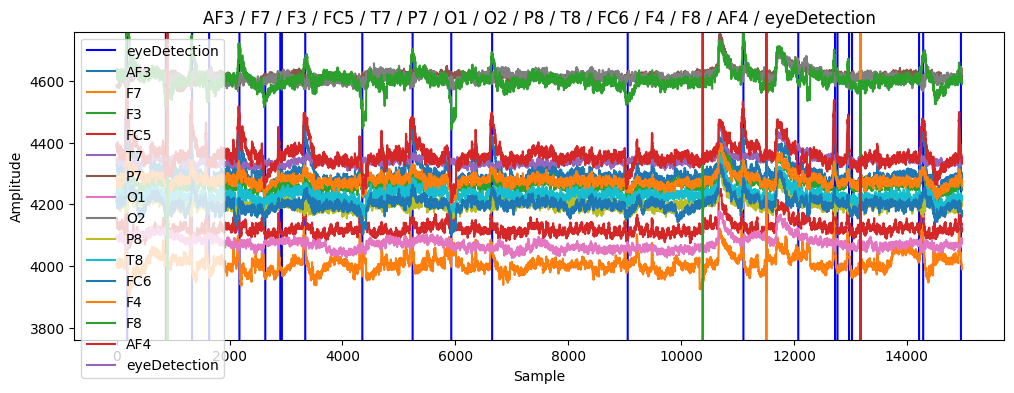

In [94]:
def plot_columns(df, columns=None, span=None, sample_range=None, title=None):
    """
    Plot specific columns of a DataFrame for comparison with optional zoom and sample range.

    Parameters:
    - df: pandas DataFrame
    - columns: list of column names to plot (default: all columns)
    - span: ±value around median to zoom (optional)
    - sample_range: tuple (start, end) to plot only part of the data (optional)
    - title: plot title (optional)
    """
    if columns is None:
        columns = df.columns.tolist()
    
    # Slice DataFrame if sample_range is provided
    if sample_range is not None:
        start, end = sample_range
        df_plot = df.iloc[start:end]
    else:
        df_plot = df

    plt.figure(figsize=(12, 4))

    # Optional: plot mask scaled
    if 'eyeDetection' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['eyeDetection']*100000, label='eyeDetection', color='blue')
    for col in columns:
        signal = df_plot[col]
        plt.plot(df_plot.index, signal, label=col)

    # Set y-limits if span is provided
    if span is not None:
        all_signals = df_plot[columns].values.flatten()
        median_val = np.median(all_signals)
        plt.ylim(median_val - span, median_val + span)

    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    if title is None:
        title = " / ".join(columns)
    plt.title(title)
    plt.legend()
    plt.show()

plot_columns(data, span=500)

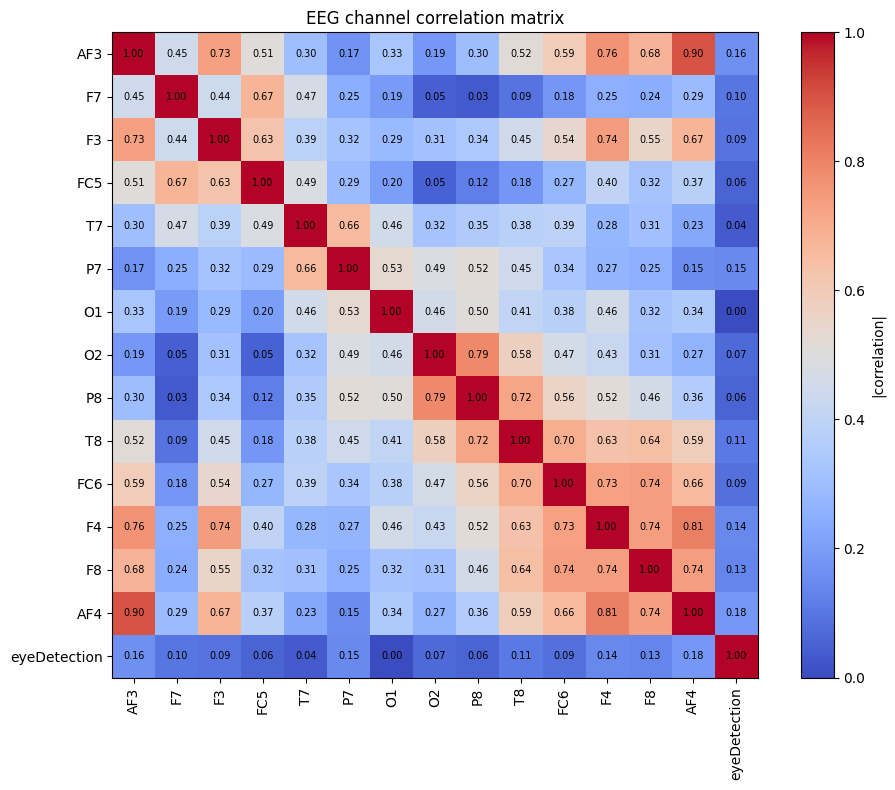

In [95]:
def inspect_and_drop_correlated_channels(
    df,
    corr_threshold=0.95,
    drop=False,
    plot=True
):
    eeg_df = df.iloc[:, :-1]
    labels = df.iloc[:, -1]

    corr = df.corr(method = 'spearman').abs()

    # ---- plot
    if plot:
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(corr.values, cmap="coolwarm", vmin=0, vmax=1)

        ax.set_xticks(np.arange(len(corr.columns)))
        ax.set_yticks(np.arange(len(corr.columns)))
        ax.set_xticklabels(corr.columns, rotation=90)
        ax.set_yticklabels(corr.columns)

        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                ax.text(j, i, f"{corr.values[i, j]:.2f}",
                        ha="center", va="center", fontsize=7)

        fig.colorbar(im, ax=ax, label="|correlation|")
        ax.set_title("EEG channel correlation matrix")
        plt.tight_layout()
        plt.show()

    # ---- optionally drop
    if not drop:
        return df.copy(), []

    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]

    print("Dropping:", to_drop)

    eeg_df_reduced = eeg_df.drop(columns=to_drop)
    df_reduced = pd.concat([eeg_df_reduced, labels], axis=1)

    return df_reduced, to_drop


data_reduced, dropped = inspect_and_drop_correlated_channels(data)


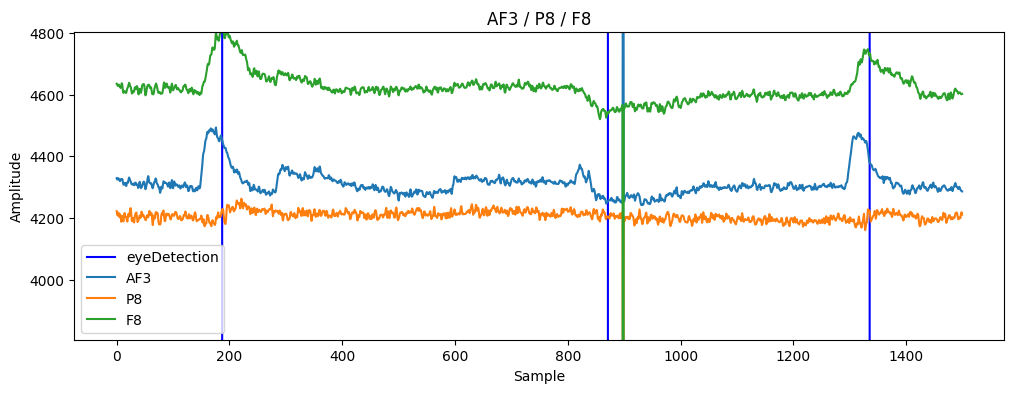

In [96]:
plot_columns(data, columns=['AF3', 'P8', 'F8'], span=500, sample_range=(0, 1500))

we want to detect the outlyers with a descrete derivative and plot the mask to see if everything works fine.

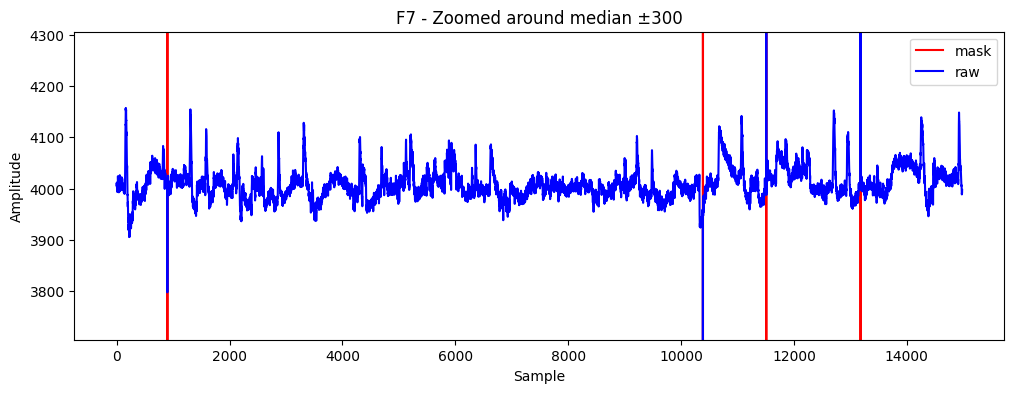

In [97]:
col = data.columns[1]  # example channel
signal = data[col]

median_val = np.median(signal)
span = 300  # ±100 around median

plt.figure(figsize=(12,4))

#derivative-based spike detection

d = np.abs(np.diff(signal, prepend=signal.iloc[0]))
mask = d > 10 * np.median(d)

#overlay mask within visible frame

#mask_y = np.full_like(signal, np.nan)
#mask_y[mask] = median_val + span0.9   # slightly above visible band
plt.plot(data.index, mask*100000000, label="mask", color='red')
plt.plot(data.index, signal, label="raw", color='blue')

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.ylim(median_val - span, median_val + span)  # zoom around median
plt.title(f"{col} - Zoomed around median ±{span}")
plt.legend()
plt.show()

In [98]:
data_clean = data.copy()
for col in data_clean.columns[:-1]:
    d = np.abs(np.diff(data_clean[col], prepend=data_clean[col].iloc[0]))
    mask = d > 10 * np.median(d)
    data_clean.loc[mask, col] = np.nan
    
    # linear interpolation
    data_clean[col] = data_clean[col].interpolate(method='linear', limit_direction='both')

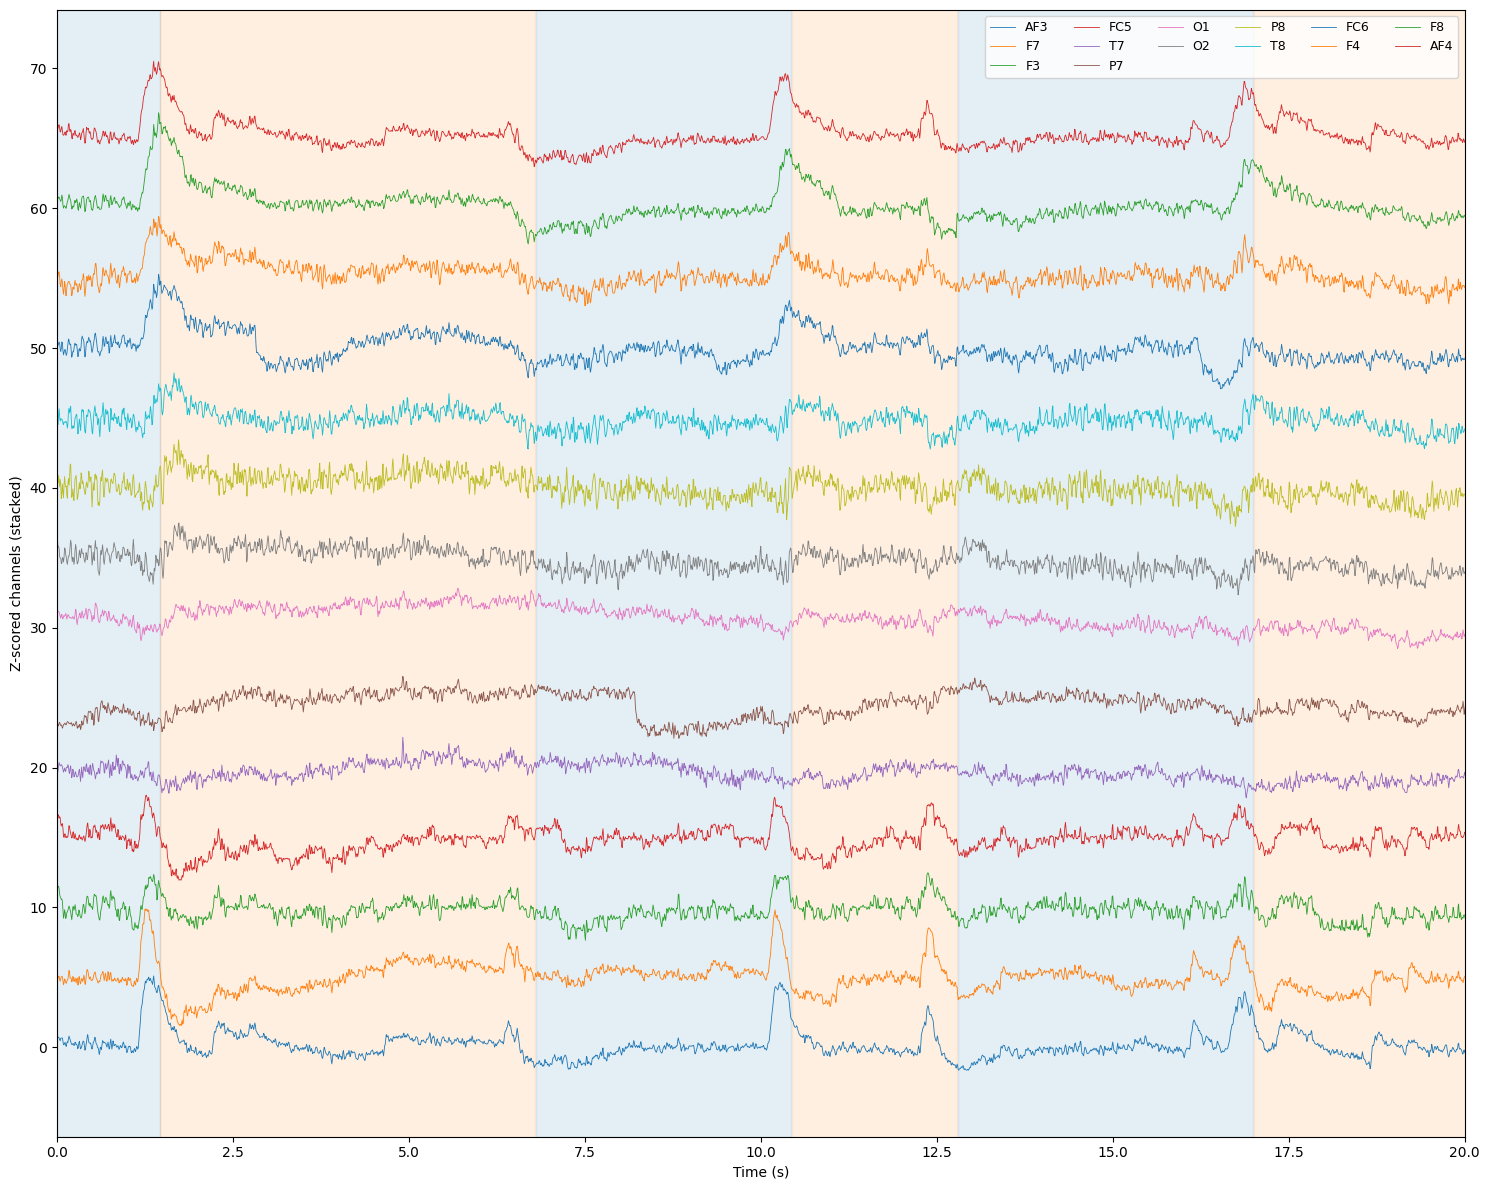

In [99]:
plot_eeg(data_clean, 128)

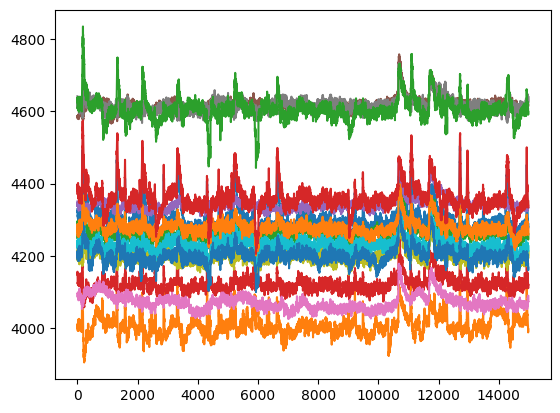

In [100]:
plt.figure()
plt.plot(data_clean.index, data_clean.iloc[:, :-1], label="raw")

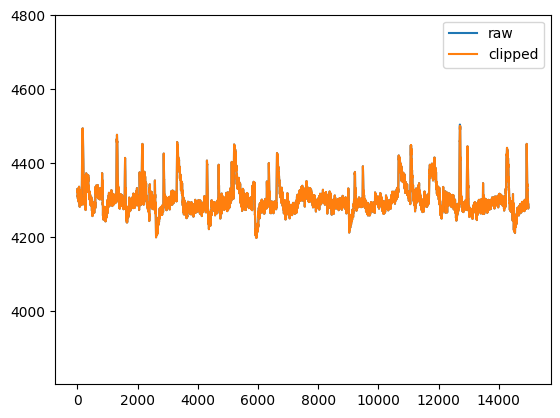

In [101]:
def clip_data(df, iqr_factor=6, plot=False):
    data_clipped = df.copy()   # VERY important

    for col in data_clipped.columns[:-1]:
        q1 = data_clipped[col].quantile(0.25)
        q3 = data_clipped[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - iqr_factor * iqr
        upper = q3 + iqr_factor * iqr

        data_clipped[col] = data_clipped[col].clip(lower, upper)

    if plot:
        col0 = data_clipped.columns[0]

        plt.figure()
        plt.plot(df.index, df[col0], label="raw")
        plt.plot(data_clipped.index, data_clipped[col0], label="clipped")

        mean = df[col0].mean()
        span = 500
        plt.ylim(mean - span, mean + span)
        plt.legend()
        plt.show()

    return data_clipped

data_clean = clip_data(data_clean, plot=True)

now i want to apply a band pass between 5 Hz  and 45 Hz

ok so what we have here now is what looks like ringing effects from the spikes. So I think this tells us that we need to take better care of the spikes befor filtering. Also what the rest of the signal looks way more noicy to me (but I also dont know how its supposed to look like)

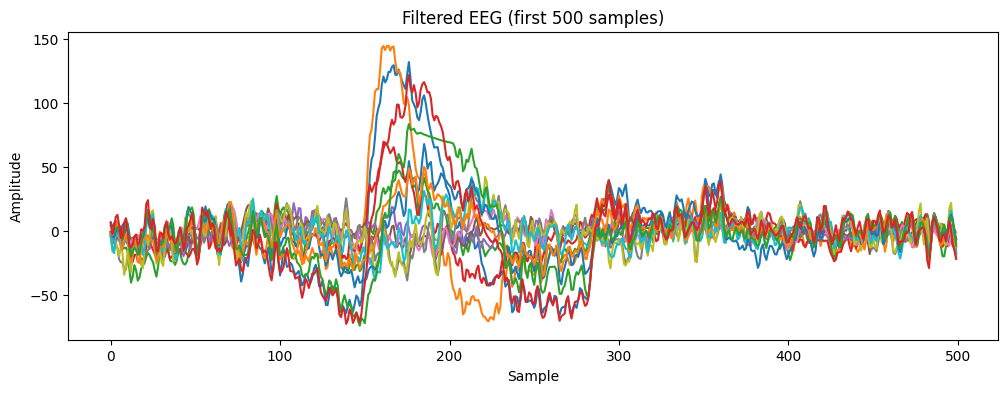

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,6.942351,-0.221418,-4.980488,-2.271328,-3.224383,-2.949721,-2.763660,-0.829633,-3.761958,-1.844917,-0.769485,-2.101585,4.291255,6.336999,0
1,3.193334,-4.717735,-0.121495,-1.015495,-11.808691,-2.527713,-2.365255,-3.439007,-15.978713,-13.874345,-4.286795,-2.966579,1.018336,-2.312646,0
2,5.229803,-3.036922,2.570210,6.060887,-15.229683,-5.738254,-2.045873,-9.713307,-15.474993,-17.185267,-4.458317,0.181162,-1.038151,1.822436,0
3,7.933654,2.414638,3.673728,6.428126,-9.872149,-6.606794,-2.147743,-10.427202,-8.105775,-4.077058,-0.732603,5.582147,1.660319,11.053705,0
4,5.045056,2.236138,0.005632,2.262621,-4.613577,-3.065736,-3.063285,-13.065209,-13.701735,4.378918,2.135270,6.914144,2.968006,12.679029,0


In [102]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def bandpass_filter_eeg(df, low_freq=0.5, high_freq=45.0, sfreq=128.0, plot_samples=500):
    """
    Apply a bandpass filter to EEG channels (all columns except the last) in a dataframe.
    
    Parameters:
        df (pd.DataFrame): Input dataframe with EEG channels and a label column as last column.
        low_freq (float): Low cutoff frequency (Hz).
        high_freq (float): High cutoff frequency (Hz).
        sfreq (float): Sampling frequency (Hz).
        plot_samples (int): Number of samples to plot for a quick check.
    
    Returns:
        pd.DataFrame: Filtered EEG dataframe with same columns as input.
    """
    eeg_cols = df.columns[:-1]
    labels = df.iloc[:, -1]

    # Extract EEG data as numpy array
    eeg_data = df[eeg_cols].to_numpy().astype(float)
    
    # Design bandpass filter
    low = low_freq / (sfreq / 2)
    high = high_freq / (sfreq / 2)
    b, a = butter(4, [low, high], btype='band')
    
    # Apply zero-phase filtering
    filtered_data = filtfilt(b, a, eeg_data, axis=0)
    
    # Quick plot
    plt.figure(figsize=(12,4))
    plt.plot(filtered_data[:plot_samples, :])
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.title("Filtered EEG (first {} samples)".format(plot_samples))
    plt.show()
    
    # Return as dataframe with original column names and label
    df_filtered = pd.DataFrame(filtered_data, columns=eeg_cols)
    df_filtered[df.columns[-1]] = labels.values
    return df_filtered

df_filtered = bandpass_filter_eeg(data_clean)
df_filtered.head()

1.068306992286503e-25
7241809.826376215


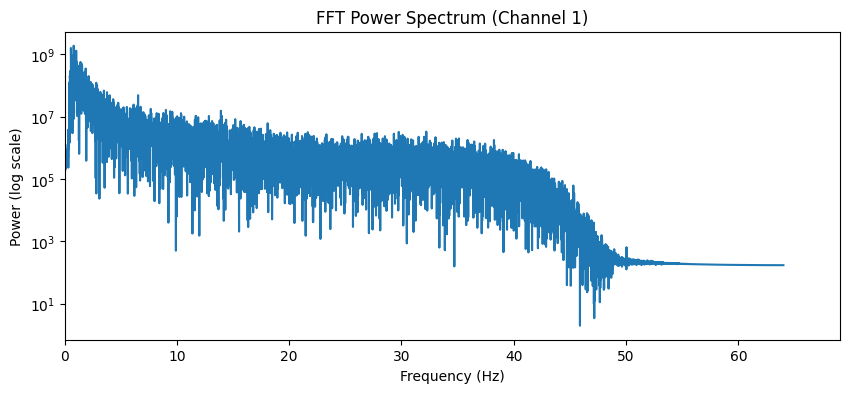

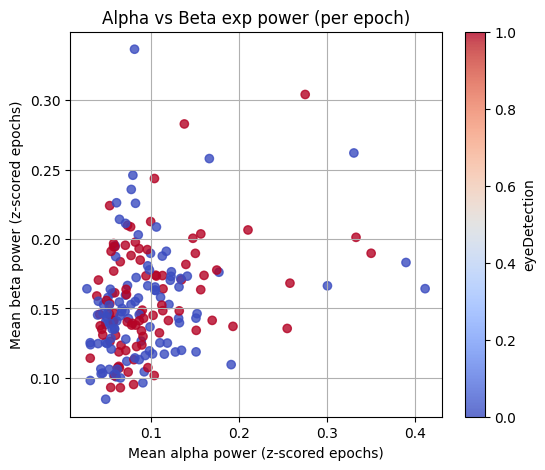

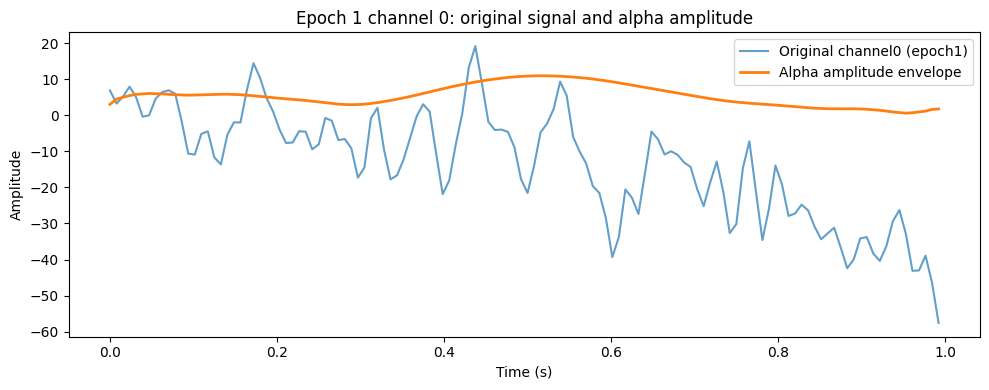

In [ ]:
sig = df_filtered.iloc[:, 0].to_numpy().astype(float)  # shape (14980, 14)

# 1️⃣ Remove DC offset (CRUCIAL)
sig = sig - np.mean(sig)

# 2️⃣ FFT
fft = np.fft.rfft(sig)
freqs = np.fft.rfftfreq(len(sig), d=1/sampling_rate)
power = np.abs(fft)**2
print(power[0])
print(power.mean())

# 3️⃣ Plot on log scale
plt.figure(figsize=(10,4))
plt.semilogy(freqs[1:], power[1:])
plt.xlim(0, sampling_rate/2 + 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (log scale)")
plt.title("FFT Power Spectrum (Channel 1)")
plt.show()

# ------------------ user request: z-score, scatter alpha/beta, alpha amplitude overlay ------------------
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt, hilbert, welch

# Ensure basic variables/functions exist before plotting
if 'sampling_rate' not in globals():
    raise RuntimeError('sampling_rate is not defined yet; run the data-loading cell first.')

if 'X' not in globals() or 'y' not in globals():
    # create epochs if missing (using data_reduced if available else data)
    source_df = data_reduced if 'data_reduced' in globals() else data
    eeg_data = source_df.iloc[:, :-1]
    labels = source_df.iloc[:, -1].to_numpy()

    epoch_len = int(1 * sampling_rate)
    step = epoch_len // 2
    X_list, y_list = [], []
    for start in range(0, len(eeg_data) - epoch_len, step):
        end = start + epoch_len
        epoch_labels = labels[start:end]
        if np.all(epoch_labels == epoch_labels[0]):
            X_list.append(eeg_data.iloc[start:end].to_numpy())
            y_list.append(epoch_labels[0])
    X = np.stack(X_list)
    y = np.array(y_list)
    print('Created X and y from epochs:', X.shape)

if 'fs' not in globals():
    fs = int(round(sampling_rate))

if 'bands' not in globals():
    bands = {'alpha': (8, 12), 'beta': (12, 30)}

# fallback for compute_bandpowers definition
if 'compute_bandpowers' not in globals():
    def compute_bandpowers(X_arr, fs_val, bands_dict):
        n_epochs, n_times, n_channels = X_arr.shape
        n_bands = len(bands_dict)
        bandpower = np.zeros((n_epochs, n_channels, n_bands))
        for i in range(n_epochs):
            for ch in range(n_channels):
                signal = X_arr[i, :, ch]
                freqs_, psd_ = welch(signal, fs=fs_val, nperseg=min(n_times, fs_val*2))
                for b_idx, (bname, (fmin, fmax)) in enumerate(bands_dict.items()):
                    idx = (freqs_ >= fmin) & (freqs_ <= fmax)
                    bandpower[i, ch, b_idx] = np.trapz(psd_[idx], freqs_[idx])
        return bandpower

# 1) z-score standardization across epochs/time/channel
X_z = X.copy().astype(float)
for ch in range(X_z.shape[2]):
    scaler = StandardScaler()
    X_z[:, :, ch] = scaler.fit_transform(X_z[:, :, ch])

# 2) compute bandpowers
bandpowers_z = compute_bandpowers(X_z, fs, bands)
alpha_idx = list(bands.keys()).index('alpha')
beta_idx = list(bands.keys()).index('beta')
alpha_power = bandpowers_z[:, :, alpha_idx].mean(axis=1)
beta_power = bandpowers_z[:, :, beta_idx].mean(axis=1)

# scatter plot alpha vs beta
plt.figure(figsize=(6,5))
plt.scatter(alpha_power, beta_power, c=y, cmap='coolwarm', alpha=0.8, edgecolor='k')
plt.xlabel('Mean alpha power (z-scored epochs)')
plt.ylabel('Mean beta power (z-scored epochs)')
plt.title('Alpha vs Beta (per epoch)')
plt.colorbar(label='eyeDetection')
plt.grid(True)
plt.show()

# 3) plot alpha amplitude over original signals for first epoch, all channels
first_epoch = X[0, :, :]
t_epoch = np.arange(first_epoch.shape[0]) / fs

plt.figure(figsize=(15,10))
for ch in range(first_epoch.shape[1]):
    ch_sig = first_epoch[:, ch]
    alpha_band = filtfilt(butter(4, [8/(fs/2), 12/(fs/2)], btype='band')[0],
                          butter(4, [8/(fs/2), 12/(fs/2)], btype='band')[1],
                          ch_sig)
    alpha_env = np.abs(hilbert(alpha_band))
    offset = ch * 5
    plt.plot(t_epoch, ch_sig/np.std(ch_sig)*2 + offset, color='grey', alpha=0.25)
    plt.plot(t_epoch, alpha_env/np.max(alpha_env)*2 + offset, color=f'C{ch % 10}', label=f'ch{ch}' if ch < 10 else None)

plt.xlabel('Time (s)')
plt.ylabel('Scaled amplitude + channel offset')
plt.title('First epoch (all channels): original vs alpha envelope')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

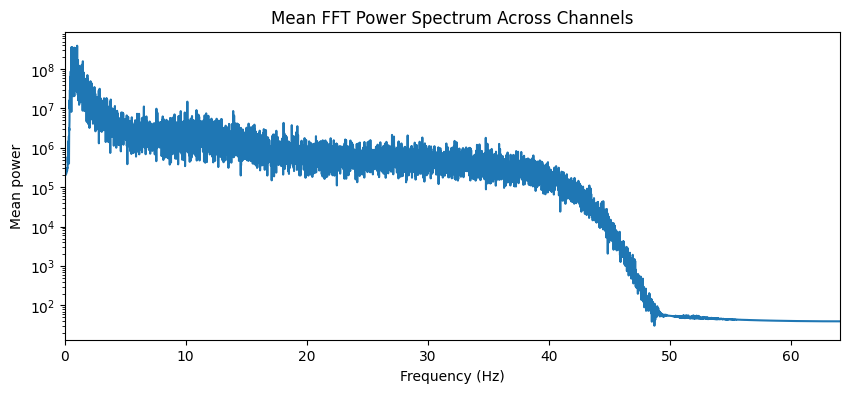

(array([0.00000000e+00, 8.54472630e-03, 1.70894526e-02, ...,
        6.39829105e+01, 6.39914553e+01, 6.40000000e+01], shape=(7491,)),
 array([[6.76304969e-24, 1.88852542e+05, 1.89226595e+05, ...,
         1.74597620e+02, 1.74597576e+02, 1.74597561e+02],
        [2.01657586e-23, 9.45940243e+04, 9.47212716e+04, ...,
         2.96208863e+01, 2.96208801e+01, 2.96208781e+01],
        [8.27180613e-25, 5.08775612e+05, 5.09265268e+05, ...,
         2.14989740e+01, 2.14989672e+01, 2.14989649e+01],
        ...,
        [4.78940806e-24, 1.91710370e+05, 1.91939773e+05, ...,
         9.41117813e-03, 9.41099384e-03, 9.41093241e-03],
        [5.49804497e-24, 2.81988112e+05, 2.82484543e+05, ...,
         2.58273958e+01, 2.58273928e+01, 2.58273918e+01],
        [2.18427381e-24, 3.16844560e+05, 3.17419621e+05, ...,
         2.32223584e+02, 2.32223522e+02, 2.32223502e+02]], shape=(14, 7491)),
 array([5.35947952e-24, 1.97940618e+05, 1.98179715e+05, ...,
        3.94834875e+01, 3.94834763e+01, 3.94834726e+

In [104]:
import pandas as pd
import numpy as np
from scipy.signal import iirnotch, filtfilt
import matplotlib.pyplot as plt

def apply_notch_filter(df, f0=50.0, Q=30.0, fs=128.0, label_col='label'):
    """
    Apply a notch filter to all EEG channels in the DataFrame, keeping the label column intact.
    
    Parameters:
    - df: DataFrame with EEG columns + label column
    - f0: notch frequency (Hz)
    - Q: quality factor of the notch
    - fs: sampling frequency (Hz)
    - label_col: name of the label column in df
    
    Returns:
    - df_notched: DataFrame with filtered EEG + original labels
    """
    eeg_cols = df.columns[:-1]
    labels = df.iloc[:, -1]

    # Extract EEG data as numpy array
    eeg_data = df[eeg_cols].to_numpy().astype(float)
    
    # Design notch filter
    b, a = iirnotch(w0=f0, Q=Q, fs=fs)
    
    # Apply zero-phase notch filter
    eeg_notched = filtfilt(b, a, eeg_data, axis=0)
    
    # Convert back to DataFrame
    df_notched = pd.DataFrame(eeg_notched, columns=eeg_cols)
    df_notched[df.columns[-1]] = labels.values
    return df_notched

df_notched = apply_notch_filter(df_filtered)
plot_mean_fft(df_notched, 128)


I did the same for the mean of all chanels. To my untrained eye this looks quite interesting, especially the part right after around 45Hz. Probably not from the brain, but its so small, we might get away with just ignoring it, since removing it could also mean loosing data.

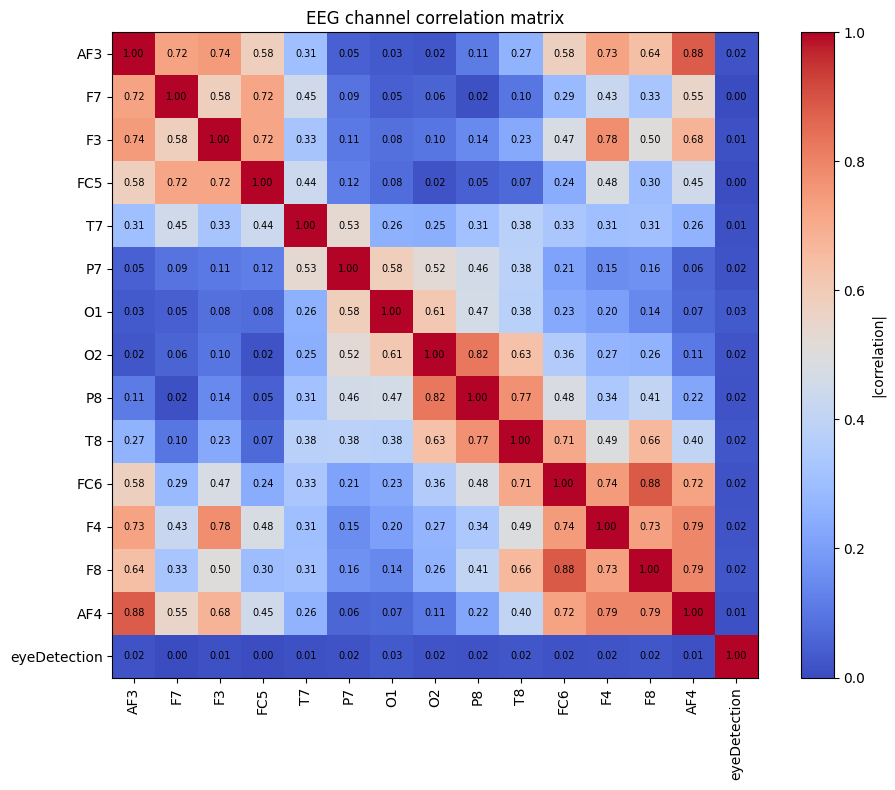

Dropping: ['P8', 'F8', 'AF4']


In [105]:
data_reduced, dropped = inspect_and_drop_correlated_channels(df_notched, corr_threshold=0.80, drop=True)

In [106]:
# Create epochs from continuous data where labels are constant
eeg_data = data_reduced.iloc[:, :-1]

epoch_len = int(1 * sampling_rate)
step = epoch_len // 2

X_list = []
y_list = []

labels = data.iloc[:, -1].to_numpy()

for start in range(0, len(eeg_data) - epoch_len, step):
    end = start + epoch_len
    epoch_labels = labels[start:end]

    if np.all(epoch_labels == epoch_labels[0]):
        X_list.append(eeg_data.iloc[start:end].to_numpy())
        y_list.append(epoch_labels[0])

X = np.stack(X_list)  # shape: (n_epochs, epoch_len, n_channels)
y = np.array(y_list)  # shape: (n_epochs,)

print("Epochs shape:", X.shape)
print("Eye open:", np.sum(y==0), "Eye closed:", np.sum(y==1))

Epochs shape: (195, 128, 11)
Eye open: 105 Eye closed: 90


In [107]:
import numpy as np
from scipy.signal import welch

def compute_bandpowers(X, fs, bands):
    """
    X: (n_epochs, n_times, n_channels)
    returns: (n_epochs, n_channels, n_bands)
    """

    n_epochs, n_times, n_channels = X.shape
    n_bands = len(bands)

    bandpower = np.zeros((n_epochs, n_channels, n_bands))

    for i in range(n_epochs):
        for ch in range(n_channels):
            signal = X[i, :, ch]

            freqs, psd = welch(signal, fs=fs, nperseg=min(n_times, fs*2))

            for b_idx, (band_name, (fmin, fmax)) in enumerate(bands.items()):
                idx = (freqs >= fmin) & (freqs <= fmax)
                power = np.trapezoid(psd[idx], freqs[idx])

                bandpower[i, ch, b_idx] = power

    return bandpower

In [108]:
def bandpower_to_features(bandpower, log_transform=True):
    """
    bandpower: (n_epochs, n_channels, n_bands)
    returns: (n_epochs, n_channels * n_bands)
    """

    features = bandpower.copy()

    if log_transform:
        features = np.log(features + 1e-10)

    # flatten
    n_epochs = features.shape[0]
    return features.reshape(n_epochs, -1)

In [109]:
import numpy as np

def bandpower_ratio(bandpower, band_names, numerator, denominator, log_transform=True):
    """
    Compute a single ratio of two bands for all channels and epochs.

    Parameters
    ----------
    bandpower : np.ndarray
        Array of shape (n_epochs, n_channels, n_bands)
    band_names : list of str
        Names of the bands in the same order as bandpower
    numerator : str
        Name of numerator band (e.g., "alpha")
    denominator : str
        Name of denominator band (e.g., "beta")
    log_transform : bool
        Whether to take log of the ratio

    Returns
    -------
    np.ndarray
        Array of shape (n_epochs, n_channels)
    """

    n_epochs, n_channels, _ = bandpower.shape
    features = np.zeros((n_epochs, n_channels))

    # Map band names to indices
    band_idx = {name: i for i, name in enumerate(band_names)}
    num_idx = band_idx[numerator]
    den_idx = band_idx[denominator]

    for i in range(n_epochs):
        for ch in range(n_channels):
            num = bandpower[i, ch, num_idx]
            den = bandpower[i, ch, den_idx]
            ratio = num / (den + 1e-10)
            if log_transform:
                ratio = np.log(ratio + 1e-10)
            features[i, ch] = ratio

    return features

In [110]:
# Define sampling frequency and EEG frequency bands
fs = int(sampling_rate)
bands = {
    #"delta": (0.5, 4),
    #"theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
}

In [111]:
# Compute band powers and create features
bandpowers = compute_bandpowers(X, fs, bands)
X_feat = bandpower_to_features(bandpowers, log_transform=True)
X_feat_ratio = bandpower_ratio(bandpowers, list(bands.keys()), "alpha", "beta", log_transform=True)
X_feat = np.concatenate([X_feat, X_feat_ratio], axis=1)
print(X_feat.shape)

(195, 33)


In [112]:
# Train Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5641025641025641
              precision    recall  f1-score   support

           0       0.58      0.71      0.64        21
           1       0.54      0.39      0.45        18

    accuracy                           0.56        39
   macro avg       0.56      0.55      0.54        39
weighted avg       0.56      0.56      0.55        39



In [113]:
import numpy as np

importances = clf.feature_importances_

n_features = len(importances)
n_channels = X.shape[2]

# Anzahl Bands automatisch berechnen
n_bands = n_features // n_channels

# Falls du Bandnamen hast → optional
band_names = list(bands.keys()) if 'bands' in globals() else [f"band{i}" for i in range(n_bands)]

feature_names = []

for ch in range(n_channels):
    for b in range(n_bands):
        band_name = band_names[b] if b < len(band_names) else f"band{b}"
        feature_names.append(f"ch{ch}_{band_name}")

indices = np.argsort(importances)[::-1]

for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

ch7_alpha: 0.0495
ch1_beta: 0.0414
ch1_alpha: 0.0379
ch9_beta: 0.0368
ch0_beta: 0.0363
ch4_beta: 0.0362
ch5_beta: 0.0342
ch10_alpha: 0.0324
ch9_alpha: 0.0320
ch6_beta: 0.0316
ch2_band2: 0.0311
ch3_band2: 0.0310
ch2_alpha: 0.0309
ch0_band2: 0.0308
ch9_band2: 0.0307
ch5_alpha: 0.0299
ch7_band2: 0.0298
ch7_beta: 0.0297
ch8_band2: 0.0296
ch1_band2: 0.0294
ch3_beta: 0.0285
ch6_band2: 0.0283
ch2_beta: 0.0278
ch8_alpha: 0.0271
ch0_alpha: 0.0267
ch3_alpha: 0.0257
ch5_band2: 0.0256
ch4_alpha: 0.0252
ch4_band2: 0.0242
ch6_alpha: 0.0237
ch8_beta: 0.0234
ch10_band2: 0.0223
ch10_beta: 0.0203


In [114]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pipeline: Skalierung + SVM
clf = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',     # Standard & meist gut
        C=1.0,
        gamma='scale',
        random_state=42
    )
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5897435897435898
              precision    recall  f1-score   support

           0       0.60      0.71      0.65        21
           1       0.57      0.44      0.50        18

    accuracy                           0.59        39
   macro avg       0.59      0.58      0.58        39
weighted avg       0.59      0.59      0.58        39

